In [140]:
### SHAP and Feature Weight Exploration

In [141]:
# Requirements

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
import shap
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from scipy.stats import shapiro
from scipy.stats import pearsonr
import gc
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from scipy.stats import zscore
import math
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import gaussian_kde

In [142]:
# read in the data

rrblup_features = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBLUP_feature_weights.csv")
svr_features = pd.read_csv("/Users/madisoncreach/Prediction_Project/SVR_weighted_features_exp.csv")

In [143]:
print(rrblup_features)

                  Marker    Effect         Phenotype
0             chr1_30159 -0.038717      SilkingGDD_L
1             chr1_39679  0.059441      SilkingGDD_L
2            chr1_325015 -0.028191      SilkingGDD_L
3            chr1_369485  0.015964      SilkingGDD_L
4            chr1_386309 -0.033882      SilkingGDD_L
...                  ...       ...               ...
4405732  chr10_151793254  0.001314  TestWeight.lb.bu
4405733  chr10_151924618 -0.004154  TestWeight.lb.bu
4405734  chr10_152067422 -0.001466  TestWeight.lb.bu
4405735  chr10_152221163 -0.000796  TestWeight.lb.bu
4405736  chr10_152424497 -0.001389  TestWeight.lb.bu

[4405737 rows x 3 columns]


In [144]:
# filter the svr features to only take the top 5%

svr_features['abs_effect'] = svr_features['Weight'].abs()

def top_5_percent(group):
    threshold = group['abs_effect'].quantile(0.95)
    return group[group['abs_effect'] >= threshold]

svr_top_5_df = svr_features.groupby('Phenotype', group_keys=False).apply(top_5_percent)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/1001413789.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  svr_top_5_df = svr_features.groupby('Phenotype', group_keys=False).apply(top_5_percent)


In [145]:
target_phenotype = "Anthesis1_L"
top_n = 10
phenotype_top_n = (
    svr_top_5_df[svr_top_5_df["Phenotype"] == target_phenotype]
    .sort_values(by="Weight", ascending=False)
    .head(top_n)
)

print(phenotype_top_n)

        Unnamed: 0          Feature    Weight    Phenotype  abs_effect
112880      112880  Zm00001eb348410  0.101887  Anthesis1_L    0.101887
112881      112881  Zm00001eb309670  0.095056  Anthesis1_L    0.095056
112882      112882  Zm00001eb017170  0.072711  Anthesis1_L    0.072711
112883      112883  Zm00001eb154700  0.070222  Anthesis1_L    0.070222
112884      112884  Zm00001eb100970  0.066136  Anthesis1_L    0.066136
112885      112885  Zm00001eb098160  0.058076  Anthesis1_L    0.058076
112886      112886  Zm00001eb005270  0.056316  Anthesis1_L    0.056316
112887      112887  Zm00001eb076480  0.055168  Anthesis1_L    0.055168
112888      112888  Zm00001eb133230  0.054479  Anthesis1_L    0.054479
112889      112889  Zm00001eb080590  0.053344  Anthesis1_L    0.053344


In [146]:
# sort the rrblup features according to absolute weight of the effect size

rr_blup_features_sorted = rrblup_features.copy()
rr_blup_features_sorted['abs_effect'] = rr_blup_features_sorted['Effect'].abs()
rr_blup_features_sorted = rr_blup_features_sorted.sort_values(by=['Phenotype', 'abs_effect'], ascending=[True, False])
rr_blup_features_sorted = rr_blup_features_sorted.drop(columns='abs_effect')

In [147]:
# now filter the dataframe such that we only have the top 5% of each markers effect

rr_blup_features_sorted_top_5_percent_df = (
    rr_blup_features_sorted.assign(abs_effect=lambda x: x['Effect'].abs())
      .groupby('Phenotype')
      .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])
      .reset_index(drop=True)
      .drop(columns='abs_effect')
)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/2676813447.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])


In [148]:
# read in rrBLUP genetic and transcriptomic feature weights

In [149]:
rrblup_features_exp_gen = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrblup_feature_weights_gen_exp.csv")

In [150]:
# sort the rrblup features according to absolute weight of the effect size

rr_blup_features_exp_gen_sorted = rrblup_features_exp_gen.copy()
rr_blup_features_exp_gen_sorted['abs_effect'] = rr_blup_features_exp_gen_sorted['Effect'].abs()
rr_blup_features_exp_gen_sorted = rr_blup_features_exp_gen_sorted.sort_values(by=['Phenotype', 'abs_effect'], ascending=[True, False])
rr_blup_features_exp_gen_sorted = rr_blup_features_exp_gen_sorted.drop(columns='abs_effect')

In [151]:
# now filter the dataframe such that we only have the top 5% of each markers effect

rr_blup_features_sorted_exp_gen_top_5_percent_df = (
    rr_blup_features_exp_gen_sorted.assign(abs_effect=lambda x: x['Effect'].abs())
      .groupby('Phenotype')
      .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])
      .reset_index(drop=True)
      .drop(columns='abs_effect')
)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/1404368415.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])


In [152]:
target_phenotype = "Anthesis1_L"
top_n = 10
phenotype_top_n = (
    rr_blup_features_sorted_exp_gen_top_5_percent_df[rr_blup_features_sorted_exp_gen_top_5_percent_df["Phenotype"] == target_phenotype]
    .sort_values(by="Effect", ascending=False)
    .head(top_n)
)

print(phenotype_top_n)

               Marker    Effect    Phenotype
9358  Zm00001eb133230  0.026217  Anthesis1_L
9359  Zm00001eb350940  0.025329  Anthesis1_L
9366  Zm00001eb169010  0.022248  Anthesis1_L
9372  Zm00001eb165520  0.019640  Anthesis1_L
9376  Zm00001eb065530  0.019240  Anthesis1_L
9378  Zm00001eb282040  0.018787  Anthesis1_L
9379  Zm00001eb035140  0.018736  Anthesis1_L
9380  Zm00001eb081750  0.018640  Anthesis1_L
9383  Zm00001eb381450  0.018221  Anthesis1_L
9385  Zm00001eb187280  0.018166  Anthesis1_L


In [153]:
# read in SVR genetic and transcriptomic feature weights

In [154]:
svr_exp_gen_feature_weights = pd.read_csv("/Users/madisoncreach/Prediction_Project/svr_exp_gen_feature_weighted_features.csv")

In [155]:
print(svr_exp_gen_feature_weights)

         Unnamed: 0          Feature        Weight         Phenotype
0                 0  Zm00001eb435850 -1.634526e+00        Unnamed: 0
1                 1  Zm00001eb302130  1.627659e+00        Unnamed: 0
2                 2  Zm00001eb111440 -1.609147e+00        Unnamed: 0
3                 3  Zm00001eb190090 -1.502826e+00        Unnamed: 0
4                 4  Zm00001eb103670 -1.361936e+00        Unnamed: 0
...             ...              ...           ...               ...
8108485     8108485  Zm00001eb116620 -9.186625e-08  TestWeight.lb.bu
8108486     8108486  Zm00001eb281340 -4.484028e-08  TestWeight.lb.bu
8108487     8108487  Zm00001eb327010 -2.443173e-08  TestWeight.lb.bu
8108488     8108488  Zm00001eb374150 -2.027922e-08  TestWeight.lb.bu
8108489     8108489   chr6_174925409  5.035804e-09  TestWeight.lb.bu

[8108490 rows x 4 columns]


In [156]:
# filter the svr features to only take the top 5%

svr_exp_gen_feature_weights['abs_effect'] = svr_exp_gen_feature_weights['Weight'].abs()

def top_5_percent(group):
    threshold = group['abs_effect'].quantile(0.95)
    return group[group['abs_effect'] >= threshold]

svr_exp_gen_top_5_df = svr_exp_gen_feature_weights.groupby('Phenotype', group_keys=False).apply(top_5_percent)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/1266890612.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  svr_exp_gen_top_5_df = svr_exp_gen_feature_weights.groupby('Phenotype', group_keys=False).apply(top_5_percent)


In [157]:
print(svr_exp_gen_top_5_df)

         Unnamed: 0          Feature    Weight Phenotype  abs_effect
187119       187119  Zm00001eb081750 -0.170664  ASIGDD_L    0.170664
187120       187120  Zm00001eb236460  0.151741  ASIGDD_L    0.151741
187121       187121  Zm00001eb309670 -0.144715  ASIGDD_L    0.144715
187122       187122  Zm00001eb320480 -0.134191  ASIGDD_L    0.134191
187123       187123  Zm00001eb170470 -0.132048  ASIGDD_L    0.132048
...             ...              ...       ...       ...         ...
1437693     1437693   chr2_218681225  0.000373    peri_N    0.000373
1437694     1437694   chr1_188972044 -0.000373    peri_N    0.000373
1437695     1437695  Zm00001eb200160 -0.000373    peri_N    0.000373
1437696     1437696  Zm00001eb358420 -0.000373    peri_N    0.000373
1437697     1437697   chr3_235042180 -0.000373    peri_N    0.000373

[405470 rows x 5 columns]


In [158]:
target_phenotype = "Anthesis1_L"
top_n = 10
phenotype_top_n = (
    svr_exp_gen_top_5_df[svr_exp_gen_top_5_df["Phenotype"] == target_phenotype]
    .sort_values(by="abs_effect", ascending=False)
    .head(top_n)
)

print(phenotype_top_n)

        Unnamed: 0          Feature    Weight    Phenotype  abs_effect
311865      311865  Zm00001eb214750 -0.032257  Anthesis1_L    0.032257
311866      311866  Zm00001eb283240 -0.030503  Anthesis1_L    0.030503
311867      311867  Zm00001eb266210 -0.027376  Anthesis1_L    0.027376
311868      311868  Zm00001eb079790 -0.026008  Anthesis1_L    0.026008
311869      311869  Zm00001eb133230  0.025400  Anthesis1_L    0.025400
311870      311870  Zm00001eb359020 -0.025188  Anthesis1_L    0.025188
311871      311871  Zm00001eb234020  0.024542  Anthesis1_L    0.024542
311872      311872  Zm00001eb337380 -0.024521  Anthesis1_L    0.024521
311873      311873  Zm00001eb153190 -0.024352  Anthesis1_L    0.024352
311874      311874  Zm00001eb060540 -0.024342  Anthesis1_L    0.024342


In [159]:
# make a bed file of the top 5% of rrBLUP feature weight markers for genes

# Assume df['Marker'] looks like "chr1_30159"
df = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBLUP_feature_weights_top_5_percent.csv", sep=r'\s+', header=None, names=["Marker", "Effect", "Phenotype"])

# Extract chromosome and position from "chr5_198504612"
df[['chrom', 'pos']] = df['Marker'].str.extract(r'(chr\d+)_(\d+)', expand=True)
df['start'] = df['pos'].astype(int)
df['end'] = df['start'] + 1
df['name'] = df['Marker']

# Final BED dataframe
bed_df = df[['chrom', 'start', 'end', 'name', 'Effect', 'Phenotype']]

# Save to BED
#bed_df.to_csv("rrBBLUP_feature_weights_top_5_percent_phenotype_effect.bed", sep='\t', header=False, index=False)

In [160]:
# make a bed file of all of the rrBLUP feature weight markers for genes

# Assume df['Marker'] looks like "chr1_30159"
df = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBLUP_feature_weights.csv", skiprows=1, header=None, names=["Marker", "Effect", "Phenotype"])

In [161]:
print(df)

                  Marker    Effect         Phenotype
0             chr1_30159 -0.038717      SilkingGDD_L
1             chr1_39679  0.059441      SilkingGDD_L
2            chr1_325015 -0.028191      SilkingGDD_L
3            chr1_369485  0.015964      SilkingGDD_L
4            chr1_386309 -0.033882      SilkingGDD_L
...                  ...       ...               ...
4405732  chr10_151793254  0.001314  TestWeight.lb.bu
4405733  chr10_151924618 -0.004154  TestWeight.lb.bu
4405734  chr10_152067422 -0.001466  TestWeight.lb.bu
4405735  chr10_152221163 -0.000796  TestWeight.lb.bu
4405736  chr10_152424497 -0.001389  TestWeight.lb.bu

[4405737 rows x 3 columns]


In [162]:
# make a bed file of all of the rrBLUP feature weight markers for genes

# Assume df['Marker'] looks like "chr1_30159"
df = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBLUP_feature_weights.csv", skiprows=1, header=None, names=["Marker", "Effect", "Phenotype"])

# Extract chromosome and position from "chr5_198504612"
df[['chrom', 'pos']] = df['Marker'].str.extract(r'(chr\d+)_(\d+)', expand=True)
df['start'] = df['pos'].astype(int)
df['end'] = df['start'] + 1
df['name'] = df['Marker']

# Final BED dataframe
bed_df = df[['chrom', 'start', 'end', 'name', 'Effect', 'Phenotype']]

# Save to BED
#bed_df.to_csv("rrBBLUP_feature_weights_phenotype_effect.bed", sep='\t', header=False, index=False)

In [163]:
# read in the genetic SVR weighted features

svr_features_genetic = pd.read_csv("/Users/madisoncreach/Prediction_Project/SVR_weighted_features_genetic.csv")

In [164]:
# filter out all rows corresponding to "Unnamed: 0"

svr_features_genetic_filter = svr_features_genetic[svr_features_genetic['Phenotype'] != 'Unnamed: 0']

In [165]:
# subset for the top 5% of markers

svr_features_genetic_filter['abs_effect'] = svr_features_genetic_filter['Weight'].abs()

def top_5_percent(group):
    threshold = group['abs_effect'].quantile(0.95)
    return group[group['abs_effect'] >= threshold]

svr_genetic_top_5_df = svr_features_genetic_filter.groupby('Phenotype', group_keys=False).apply(top_5_percent)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/3854221895.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  svr_features_genetic_filter['abs_effect'] = svr_features_genetic_filter['Weight'].abs()
/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/3854221895.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  svr_genetic_top_5_df = svr_features_genetic_filter.groupby('Phenotype', group_keys=False).apply(top_5_percent)


In [166]:
# now look at the overlap between the svr genetic top markers and the top markers from rrblup
all_phenotypes = set(rr_blup_features_sorted_top_5_percent_df['Phenotype']).union(set(svr_genetic_top_5_df['Phenotype']))

# Dictionary to store the overlap counts
overlap_results = []

for phenotype in all_phenotypes:
    genes1 = set(svr_genetic_top_5_df[svr_genetic_top_5_df['Phenotype'] == phenotype]['Feature'])
    genes2 = set(rr_blup_features_sorted_top_5_percent_df[rr_blup_features_sorted_top_5_percent_df['Phenotype'] == phenotype]['Marker'])
    
    common_genes = genes1.intersection(genes2)
    
    overlap_results.append({
        "Phenotype": phenotype,
        "Genes_in_df1": len(genes1),
        "Genes_in_df2": len(genes2),
        "Genes_in_common": len(common_genes)
    })

# Convert to DataFrame for display
overlap_df = pd.DataFrame(overlap_results)

# View or save
print(overlap_df)

           Phenotype  Genes_in_df1  Genes_in_df2  Genes_in_common
0    StalkDiameter_D          1708          1708              821
1              Fat_K          1708          1708              884
2         Moisture_K          1708          1708              799
3    KernelsPerRow_J          1708          1708              857
4     SAMarcLength_N          1708          1708              804
..               ...           ...           ...              ...
126            ASI_L          1708          1708              835
127    PlantHeight_J          1708          1708             1031
128  Tassellength2_C          1708          1708              920
129    Ncombustion_K          1708          1708              843
130       Nkjeltec_K          1708          1708              822

[131 rows x 4 columns]


In [167]:
# read in the expression rrblup feature weights

rrblup_features_exp = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrblup_feature_weights_exp.csv")

In [168]:
# sort the rrblup features according to absolute weight of the effect size

rr_blup_features_sorted_exp = rrblup_features_exp.copy()
rr_blup_features_sorted_exp['abs_effect'] = rr_blup_features_sorted_exp['Effect'].abs()
rr_blup_features_sorted_exp = rr_blup_features_sorted_exp.sort_values(by=['Phenotype', 'abs_effect'], ascending=[True, False])
rr_blup_features_sorted_exp = rr_blup_features_sorted_exp.drop(columns='abs_effect')

In [169]:
# now filter the dataframe such that we only have the top 5% of each markers effect

rr_blup_features_sorted_exp_top_5_percent_df = (
    rr_blup_features_sorted_exp.assign(abs_effect=lambda x: x['Effect'].abs())
      .groupby('Phenotype')
      .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])
      .reset_index(drop=True)
      .drop(columns='abs_effect')
)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/1282120181.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])


In [170]:
target_phenotype = "Anthesis1_L"
top_n = 10
phenotype_top_n = (
    rr_blup_features_sorted_exp_top_5_percent_df[rr_blup_features_sorted_exp_top_5_percent_df["Phenotype"] == target_phenotype]
    .sort_values(by="Effect", ascending=False)
    .head(top_n)
)

print(phenotype_top_n)

               Marker    Effect    Phenotype
4237  Zm00001eb133230  0.049202  Anthesis1_L
4239  Zm00001eb350940  0.045439  Anthesis1_L
4245  Zm00001eb065530  0.042614  Anthesis1_L
4247  Zm00001eb389040  0.040605  Anthesis1_L
4249  Zm00001eb169010  0.039048  Anthesis1_L
4250  Zm00001eb288990  0.038028  Anthesis1_L
4253  Zm00001eb018130  0.037221  Anthesis1_L
4256  Zm00001eb165520  0.036409  Anthesis1_L
4257  Zm00001eb100970  0.035877  Anthesis1_L
4264  Zm00001eb187280  0.034321  Anthesis1_L


In [171]:
svr_features_exp = pd.read_csv("/Users/madisoncreach/Prediction_Project/SVR_weighted_features_exp.csv")

In [172]:
# filter the svr features to only take the top 5%

svr_features_exp['abs_effect'] = svr_features_exp['Weight'].abs()

def top_5_percent(group):
    threshold = group['abs_effect'].quantile(0.95)
    return group[group['abs_effect'] >= threshold]

svr_top_5_exp_df = svr_features_exp.groupby('Phenotype', group_keys=False).apply(top_5_percent)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/1236609295.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  svr_top_5_exp_df = svr_features_exp.groupby('Phenotype', group_keys=False).apply(top_5_percent)


In [173]:
# now look at the overlap between the svr genetic top markers and the top markers from rrblup
all_phenotypes = set(rr_blup_features_sorted_exp_top_5_percent_df['Phenotype']).union(set(svr_top_5_exp_df['Phenotype']))

# Dictionary to store the overlap counts
overlap_results = []

for phenotype in all_phenotypes:
    genes1 = set(svr_top_5_exp_df[svr_top_5_exp_df['Phenotype'] == phenotype]['Feature'])
    genes2 = set(rr_blup_features_sorted_exp_top_5_percent_df[rr_blup_features_sorted_exp_top_5_percent_df['Phenotype'] == phenotype]['Marker'])
    
    common_genes = genes1.intersection(genes2)
    
    overlap_results.append({
        "Phenotype": phenotype,
        "Genes_in_df1": len(genes1),
        "Genes_in_df2": len(genes2),
        "Genes_in_common": len(common_genes)
    })

# Convert to DataFrame for display
overlap_df = pd.DataFrame(overlap_results)

# View or save
print(overlap_df)

           Phenotype  Genes_in_df1  Genes_in_df2  Genes_in_common
0    StalkDiameter_D          1411          1412              716
1              Fat_K          1411          1412              760
2         Moisture_K          1411          1412              701
3    KernelsPerRow_J          1411          1412              623
4     SAMarcLength_N          1411          1412              731
..               ...           ...           ...              ...
126            ASI_L          1411          1412              599
127    PlantHeight_J          1411          1412              713
128  Tassellength2_C          1411          1412              724
129    Ncombustion_K          1411          1412              722
130       Nkjeltec_K          1411          1412              731

[131 rows x 4 columns]


In [174]:
# count the number of unique phenotypes in the rrblup features exp

unique_count = rr_blup_features_sorted_exp_top_5_percent_df['Phenotype'].nunique()
print(unique_count)

129


In [175]:
# Count the number of unique phenotypes each gene (Feature) appears in
gene_phenotype_counts = rr_blup_features_sorted_exp_top_5_percent_df.groupby('Marker')['Phenotype'].nunique()

# Sort genes by the number of phenotypes they appear in (descending)
top_genes = gene_phenotype_counts.sort_values(ascending=False)

# Optional: get top N genes (e.g., top 10)
top_genes.head(10)


Marker
Zm00001eb346330    99
Zm00001eb337380    99
Zm00001eb334350    97
Zm00001eb181260    92
Zm00001eb262910    90
Zm00001eb182190    90
Zm00001eb051930    89
Zm00001eb093090    89
Zm00001eb084470    89
Zm00001eb305360    89
Name: Phenotype, dtype: int64

In [176]:
# Count the number of unique phenotypes each gene (Feature) appears in
gene_phenotype_counts = svr_top_5_exp_df.groupby('Feature')['Phenotype'].nunique()

# Sort genes by the number of phenotypes they appear in (descending)
top_genes = gene_phenotype_counts.sort_values(ascending=False)

# Optional: get top N genes (e.g., top 10)
top_genes.head(10)

Feature
Zm00001eb084380    91
Zm00001eb254310    88
Zm00001eb337380    84
Zm00001eb262910    84
Zm00001eb181260    83
Zm00001eb051930    82
Zm00001eb348410    82
Zm00001eb042410    81
Zm00001eb164380    81
Zm00001eb382460    81
Name: Phenotype, dtype: int64

In [177]:
# re-read in the output bed file with closest genes mapped to nearest gene with Phenotype attached

bedtools_output_pheno = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBBLUP_feature_weights_top_5_percent_closest_gene.bed", sep='\t', header=None)

bedtools_output_pheno.columns = [
    'chr', 'start', 'end', 'marker_name', 'Phenotype',
    'gene_chr', 'gene_start', 'gene_end', 'gene_id', 'distance'
]

In [178]:
# look at overlap between rrBLUP genetic (assigned to closest gene) and rrBLUP expression

# Get all unique phenotypes from both DataFrames
all_phenotypes = set(bedtools_output_pheno['Phenotype']).union(set(rr_blup_features_sorted_exp_top_5_percent_df['Phenotype']))

# Dictionary to store the overlap counts
overlap_results = []

for phenotype in all_phenotypes:
    genes1 = set(rr_blup_features_sorted_exp_top_5_percent_df[rr_blup_features_sorted_exp_top_5_percent_df['Phenotype'] == phenotype]['Marker'])
    genes2 = set(bedtools_output_pheno[bedtools_output_pheno['Phenotype'] == phenotype]['gene_id'])
    
    common_genes = genes1.intersection(genes2)
    
    overlap_results.append({
        "Phenotype": phenotype,
        "Genes_in_df1": len(genes1),
        "Genes_in_df2": len(genes2),
        "Genes_in_common": len(common_genes)
    })

# Convert to DataFrame for display
overlap_df = pd.DataFrame(overlap_results)

# View or save
print(overlap_df)
# overlap_df.to_csv("phenotype_gene_overlap.csv", index=False)

           Phenotype  Genes_in_df1  Genes_in_df2  Genes_in_common
0    StalkDiameter_D          1412          1647               49
1         Moisture_K          1412          1637               61
2              Fat_K          1412          1631               61
3     SAMarcLength_N          1412          1626               62
4    KernelsPerRow_J          1412          1646               58
..               ...           ...           ...              ...
124            ASI_L          1412          1627               57
125    PlantHeight_J          1412          1652               68
126  Tassellength2_C          1412          1636               57
127    Ncombustion_K          1412          1625               59
128       Nkjeltec_K          1412          1625               60

[129 rows x 4 columns]


In [179]:
# re-read in the output bed file with markers mapped to all genes within 50kb with phenotype attached

bedtools_output_pheno_50000 = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBBLUP_feature_weights_top_5_percent_phenotype_sorted_50000.bed", sep='\t', header=None)

bedtools_output_pheno_50000.columns = [
    'gene_chr', 'gene_start', 'gene_end', 'gene_id', 
    'chr', 'start', 'end', 'marker_name', 'Phenotype'
]

In [180]:
# look at overlap of top 5% from genetic rrBLUP (assigned to multiple genes) and then the top 5% from expression rrBLUP
# then calculate the hypergeometric test to see if the overlap is significant

from scipy.stats import hypergeom
import pandas as pd

# The total N is taken from unique features in Marker
N = len(set(rrblup_features_exp['Marker']))

# List to store results
overlap_results = []

# Get all unique phenotypes
all_phenotypes = set(bedtools_output_pheno_50000['Phenotype']).union(
    rr_blup_features_sorted_exp_top_5_percent_df['Phenotype']
)

for phenotype in all_phenotypes:
    genes_a = set(rr_blup_features_sorted_exp_top_5_percent_df[
        rr_blup_features_sorted_exp_top_5_percent_df['Phenotype'] == phenotype
    ]['Marker'])

    genes_b = set(bedtools_output_pheno_50000[
        bedtools_output_pheno_50000['Phenotype'] == phenotype
    ]['gene_id'])

    x = len(genes_a & genes_b)   # Overlap
    K = len(genes_a)             # List A size
    n = len(genes_b)             # List B size

    # Hypergeometric test: P(X >= x)
    p_val = hypergeom.sf(x - 1, N, K, n)

    overlap_results.append({
        "Phenotype": phenotype,
        "Genes_in_df1": K,
        "Genes_in_df2": n,
        "Genes_in_common": x,
        "Hypergeometric_pval": p_val
    })

# Convert to DataFrame
overlap_df = pd.DataFrame(overlap_results)


In [181]:
# re-read in the output genetic bed file with closest genes mapped to nearest gene with Phenotype and effect attached

bedtools_output_pheno_effect = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrBBLUP_feature_weights_closest_gene_effect_phenotype.bed", sep='\t', header=None)

bedtools_output_pheno_effect.columns = [
    'chr', 'start', 'end', 'marker_name', 'Effect', 'Phenotype',
    'gene_chr', 'gene_start', 'gene_end', 'Marker'
    ]


In [182]:
merged_df_rrblup_exp_rrblup_gen = pd.merge(bedtools_output_pheno_effect, rrblup_features_exp, on=['Marker', 'Phenotype'])

In [183]:
print(merged_df_rrblup_exp_rrblup_gen.columns)

Index(['chr', 'start', 'end', 'marker_name', 'Effect_x', 'Phenotype',
       'gene_chr', 'gene_start', 'gene_end', 'Marker', 'Effect_y'],
      dtype='object')


In [184]:
def signed_log10(x):
    return np.sign(x) * np.log10(np.abs(x))

In [185]:
def log10_abs_floor(x):
    x = np.abs(x)
    x = np.where(x < 1e-6, 1e-6, x)
    return np.log10(x)

In [186]:
print(merged_df_rrblup_exp_rrblup_gen)

          chr      start        end     marker_name  Effect_x  \
0        chr1      30159      30160      chr1_30159  0.001506   
1        chr1      30159      30160      chr1_30159 -0.059944   
2        chr1      30159      30160      chr1_30159 -0.004581   
3        chr1      30159      30160      chr1_30159 -0.000135   
4        chr1      30159      30160      chr1_30159 -0.047503   
...       ...        ...        ...             ...       ...   
3241894  chr9  162612496  162612497  chr9_162612496  0.006275   
3241895  chr9  162612496  162612497  chr9_162612496 -0.006627   
3241896  chr9  162612496  162612497  chr9_162612496 -0.163880   
3241897  chr9  162612496  162612497  chr9_162612496  0.122728   
3241898  chr9  162612496  162612497  chr9_162612496  0.007066   

                      Phenotype gene_chr  gene_start   gene_end  \
0                   Anthesis7_H     chr1       34616      40204   
1                    Anthesis_G     chr1       34616      40204   
2                 

In [188]:

phenotype_list = merged_df_rrblup_exp_rrblup_gen['Phenotype'].unique()

for pheno in phenotype_list:
    sub = merged_df_rrblup_exp_rrblup_gen[
        merged_df_rrblup_exp_rrblup_gen['Phenotype'] == pheno
    ]

    # Extract the effect values
    x = log10_abs_floor(sub['Effect_x'])
    y = log10_abs_floor(sub['Effect_y'])

    r, p_value = pearsonr(x, y)

    # Plot hexbin
    plt.figure(figsize=(8, 6))
    hb = plt.hexbin(
        x, y,
        gridsize=50,          # smaller = finer hexes, larger = coarser
        cmap='viridis',
        bins='log'            # log color scaling (useful for dense regions)
    )
    plt.colorbar(hb, label='log10(N)')  # color scale bar

    plt.xlabel('Genetic Feature Weight')
    plt.ylabel('Expression Feature Weights')
    plt.title(f'Hexbin Plot of Gene Effects for {pheno}')

    # Add correlation stats
    plt.text(
        0.05, 0.95,
        f"Pearson r = {r:.3f}\np = {p_value:.2e}",
        transform=plt.gca().transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.rcParams['pdf.fonttype'] = 42
    #plt.savefig(f"/Users/madisoncreach/Prediction_Project/Hex_Plots/{pheno}.pdf")
    plt.close()


/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/910533375.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_value = pearsonr(x, y)


In [189]:
# now perform feature enrichment to see if multi-omics models are more likely to have a certain kind of feature highly weighted

In [190]:
# read in the genetic and expression multi-omics feature weights

rrblup_features_gen_exp = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrblup_feature_weights_gen_exp.csv")

In [191]:
# sort the rrblup features according to absolute weight of the effect size

rr_blup_features_sorted_gen_exp = rrblup_features_gen_exp.copy()
rr_blup_features_sorted_gen_exp['abs_effect'] = rr_blup_features_sorted_gen_exp['Effect'].abs()
rr_blup_features_sorted_gen_exp = rr_blup_features_sorted_gen_exp.sort_values(by=['Phenotype', 'abs_effect'], ascending=[True, False])
rr_blup_features_sorted_gen_exp = rr_blup_features_sorted_gen_exp.drop(columns='abs_effect')

In [192]:
# now filter the dataframe such that we only have the top 5% of each markers effect

rr_blup_features_sorted_gen_exp_top_5_percent_df = (
    rr_blup_features_sorted_gen_exp.assign(abs_effect=lambda x: x['Effect'].abs())
      .groupby('Phenotype')
      .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])
      .reset_index(drop=True)
      .drop(columns='abs_effect')
)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_898/2477517027.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])


In [193]:
# now add a Feature Type column to the dataframe with a label for each of the data types

rr_blup_features_sorted_gen_exp_top_5_percent_df["FeatureType"] = rr_blup_features_sorted_gen_exp_top_5_percent_df["Marker"].apply(lambda x: "Expression" if x.startswith("Zm") else "Genetic")

In [194]:
# there is a possibility that there are many top expression features that have overall a smaller effect than a certain number of genetic features
# to address we will take the absolute value of the effect sizes and quickly sum them according to phenotype

In [195]:
# now add an absolute effect column for the feature effects

rr_blup_features_sorted_gen_exp_top_5_percent_df["absolute_effect"] = rr_blup_features_sorted_gen_exp_top_5_percent_df["Effect"].abs()

In [196]:
# now look at each feature type sum for each phenotype

sum_by_pheno_and_type = (
    rr_blup_features_sorted_gen_exp_top_5_percent_df
    .groupby(["Phenotype", "FeatureType"])["absolute_effect"]
    .sum()
    .reset_index()
    .sort_values(["Phenotype", "FeatureType"])
)

In [197]:
# now look at them

print(sum_by_pheno_and_type)

             Phenotype FeatureType  absolute_effect
0             ASIGDD_L  Expression        38.439407
1             ASIGDD_L     Genetic        31.352403
2                ASI_L  Expression         0.893530
3                ASI_L     Genetic         0.765245
4    AnkomCrudeFiber_K  Expression         0.261052
..                 ...         ...              ...
253            avgEH_N     Genetic        16.485066
254      dry_g_per_ear  Expression        39.096421
255      dry_g_per_ear     Genetic        25.216378
256             peri_N  Expression         0.736840
257             peri_N     Genetic         0.399124

[258 rows x 3 columns]


In [198]:
# now get a count of each of the feature types according to their respective phenotype

rrblup_gen_exp_top_5_counts = rr_blup_features_sorted_gen_exp_top_5_percent_df.groupby(["Phenotype", "FeatureType"]).size().unstack(fill_value=0)

In [199]:
# now do the same for the full dataset to get a set of background counts

rr_blup_features_sorted_gen_exp["FeatureType"] = rr_blup_features_sorted_gen_exp["Marker"].apply(lambda x: "Expression" if x.startswith("Zm") else "Genetic")
rrblup_gen_exp_background_counts = rr_blup_features_sorted_gen_exp.groupby(["Phenotype", "FeatureType"]).size().unstack(fill_value=0)


In [200]:
from scipy.stats import fisher_exact

for pheno in df["Phenotype"].unique():
    top = rrblup_gen_exp_top_5_counts.loc[pheno]
    background = rrblup_gen_exp_background_counts.loc[pheno]

    # Contingency table
    top_counts = [top["Expression"], top["Genetic"]]
    rest_counts = [background["Expression"] - top["Expression"], background["Genetic"] - top["Genetic"]]
    
    contingency = [top_counts, rest_counts]
    oddsratio, p_value = fisher_exact(contingency)

    print(f"{pheno}: p={p_value:.4g}, odds ratio={oddsratio:.2f}")

SilkingGDD_L: p=4.63e-35, odds ratio=1.58
AnthesisGDD_L: p=2.23e-29, odds ratio=1.51
ASIGDD_L: p=1.739e-06, odds ratio=1.19
Silking_L: p=1.282e-46, odds ratio=1.70
Anthesis1_L: p=5.741e-74, odds ratio=1.96
ASI_L: p=0.0006384, odds ratio=1.13
PlantHeight_L: p=1.187e-24, odds ratio=1.46
EarHeight_L: p=1.567e-22, odds ratio=1.43
PH.EH_L: p=3.525e-26, odds ratio=1.48
PHdivDTR_L: p=3.933e-20, odds ratio=1.40
EarDiameter1_M: p=3.721e-25, odds ratio=1.46
EarDiameterAbove_M: p=2.729e-28, odds ratio=1.50
EarDiameterBelow_M: p=5.735e-31, odds ratio=1.53
Nodes_M: p=8.849e-31, odds ratio=1.53
PlantHeight_M: p=5.549e-20, odds ratio=1.40
EarHeight_M: p=3.712e-31, odds ratio=1.53
SAMheight_M: p=2.651e-32, odds ratio=1.55
SAMRadius_M: p=2.83e-33, odds ratio=1.56
StalkDiamThick_N: p=4.279e-62, odds ratio=1.85
StalkDiamThin_N: p=2.45e-55, odds ratio=1.79
BraceRoot_N: p=7.182e-36, odds ratio=1.59
StalkArea_N: p=1.477e-53, odds ratio=1.77
peri_N: p=1.632e-59, odds ratio=1.83
avgEH_N: p=1.142e-51, odds rat

In [201]:
from scipy.stats import fisher_exact

for pheno in df["Phenotype"].unique():
    top = rrblup_gen_exp_top_5_counts.loc[pheno]
    background = rrblup_gen_exp_background_counts.loc[pheno]

    # Contingency table
    top_counts = [top["Genetic"], top["Expression"]]
    rest_counts = [background["Genetic"] - top["Genetic"], background["Expression"] - top["Expression"]]
    
    contingency = [top_counts, rest_counts]
    oddsratio, p_value = fisher_exact(contingency)

    print(f"{pheno}: p={p_value:.4g}, odds ratio={oddsratio:.2f}")

SilkingGDD_L: p=4.63e-35, odds ratio=0.63
AnthesisGDD_L: p=2.23e-29, odds ratio=0.66
ASIGDD_L: p=1.739e-06, odds ratio=0.84
Silking_L: p=1.282e-46, odds ratio=0.59
Anthesis1_L: p=5.741e-74, odds ratio=0.51
ASI_L: p=0.0006384, odds ratio=0.88
PlantHeight_L: p=1.187e-24, odds ratio=0.69
EarHeight_L: p=1.567e-22, odds ratio=0.70
PH.EH_L: p=3.525e-26, odds ratio=0.68
PHdivDTR_L: p=3.933e-20, odds ratio=0.71
EarDiameter1_M: p=3.721e-25, odds ratio=0.68
EarDiameterAbove_M: p=2.729e-28, odds ratio=0.67
EarDiameterBelow_M: p=5.735e-31, odds ratio=0.65
Nodes_M: p=8.849e-31, odds ratio=0.65
PlantHeight_M: p=5.549e-20, odds ratio=0.71
EarHeight_M: p=3.712e-31, odds ratio=0.65
SAMheight_M: p=2.651e-32, odds ratio=0.65
SAMRadius_M: p=2.83e-33, odds ratio=0.64
StalkDiamThick_N: p=4.279e-62, odds ratio=0.54
StalkDiamThin_N: p=2.45e-55, odds ratio=0.56
BraceRoot_N: p=7.182e-36, odds ratio=0.63
StalkArea_N: p=1.477e-53, odds ratio=0.57
peri_N: p=1.632e-59, odds ratio=0.55
avgEH_N: p=1.142e-51, odds rat

In [202]:
phenotype_to_group = {
    'LastJuvenileLeaf_A': 'Vegetative', 'Anthesis_A': 'FloweringTime', 'Silking_A': 'FloweringTime', 
    'SMV7DAI_B': 'Disease', 'TasselLength1_C': 'Inflorescence', 'SpikeLength1_C': 'Inflorescence', 
    'BranchNumber1_C': 'Inflorescence', 'TasselWeight1_C': 'Inflorescence', 'BranchZoneLength_C': 'Inflorescence', 
    'BranchDensity_C': 'Inflorescence', 'Tassellength2_C': 'Inflorescence', 'SpikeLength2_C': 'Inflorescence', 
    'BranchNumber2_C': 'Inflorescence', 'TasselWeight2_C': 'Inflorescence', 'Compactness_C': 'Inflorescence', 
    'PerimeterLength_C': 'Inflorescence', 'SkeletonLength_C': 'Inflorescence', 'StalkDiameter_D': 'Vegetative', 
    'PlantHeight_D': 'Vegetative', 'VascularBundleDensity_D': 'Cellular/Biochemical', 
    'BulliformColNumber2_E': 'Cellular/Biochemical', 'BulliformColWidth2_E': 'Cellular/Biochemical', 
    'BulliformColNumber3_E': 'Cellular/Biochemical', 'BulliformColWidth3_E': 'Cellular/Biochemical', 
    'PlantHeight_G': 'Vegetative', 'Anthesis_G': 'FloweringTime', 'BiomassYield_G': 'Vegetative', 
    'Anthesis4_H': 'FloweringTime', 'Anthesis5_H': 'FloweringTime', 'Anthesis6_H': 'FloweringTime', 
    'Anthesis7_H': 'FloweringTime', 'RootAngle_I': 'Root', 'SouthernRustSeverityScore_J': 'Disease', 
    'PlantHeight_J': 'Vegetative', 'ExtantLeafNumber1_J': 'Vegetative', 'ExtantLeafNumber2_J': 'Vegetative', 
    'LeafWidth_J': 'Vegetative', 'LeafLength_J': 'Vegetative', 'LeafAreaIndex_J': 'Vegetative', 
    'Silking_J': 'FloweringTime', 'Anthesis_J': 'FloweringTime', 'BranchZoneLength_J': 'Inflorescence', 
    'EarLength_J': 'Inflorescence', 'EarWidth_J': 'Inflorescence', 'EarFilledLength_J': 'Inflorescence', 
    'KernelRowNumber_J': 'Inflorescence', 'KernelsPerRow_J': 'Inflorescence', 'GrainPercentMoisture_J': 'Agronomic', 
    'TotalGrainMassGrams_J': 'Agronomic', 'BushelAcreEquivalent_J': 'Agronomic', 'CobWeightGrams_J': 'Agronomic', 
    'HundredKernelMassGrams_J': 'Agronomic', 'LeafAngle_J': 'Vegetative', 'Moisture_K': 'SeedComposition', 
    'Protein_K': 'SeedComposition', 'Fat_K': 'SeedComposition', 'Fiber_K': 'SeedComposition', 
    'Starch_K': 'SeedComposition', 'AnkomCrudeFiber_K': 'SeedComposition', 'CrudeAsh_K': 'SeedComposition', 
    'CrudeFat_K': 'SeedComposition', 'CrudeFiber_K': 'SeedComposition', 'Ncombustion_K': 'SeedComposition', 
    'Nkjeltec_K': 'SeedComposition', 'TotSugar_K': 'SeedComposition', 'SilkingGDD_L': 'FloweringTime', 
    'AnthesisGDD_L': 'FloweringTime', 'ASIGDD_L': 'FloweringTime', 'Silking_L': 'FloweringTime', 
    'Anthesis1_L': 'FloweringTime', 'ASI_L': 'FloweringTime', 'PlantHeight_L': 'Vegetative', 
    'EarHeight_L': 'Vegetative', 'PHdivDTR_L': 'Vegetative', 'EarDiameter1_M': 'Inflorescence', 
    'EarDiameterAbove_M': 'Inflorescence', 'EarDiameterBelow_M': 'Inflorescence', 'Nodes_M': 'Vegetative', 
    'PlantHeight_M': 'Vegetative', 'EarHeight_M': 'Vegetative', 'SAMheight_M': 'Cellular/Biochemical', 
    'SAMRadius_M': 'Cellular/Biochemical', 'StalkDiamThick_N': 'Vegetative', 'StalkDiamThin_N': 'Vegetative', 
    'BraceRoot_N': 'Root', 'StalkArea_N': 'Vegetative', 'peri_N': 'Vegetative', 'avgEH_N': 'Vegetative', 
    'PlantHeight_N': 'Vegetative', 'SAMLog2vol_N': 'Cellular/Biochemical', 'SAMarcLength_N': 'Cellular/Biochemical', 
    'RootArea1_O': 'Root', 'RootArea2_O': 'Root', 'RootArea3_O': 'Root', 'RootArea4_O': 'Root', 'RootWidth1_O': 'Root', 
    'RootWidth2_O': 'Root', 'RootWidth3_O': 'Root', 'RootWidth4_O': 'Root', 'RootAngle1_O': 'Root', 'RootAngle2_O': 'Root', 
    'RootDepth1_O': 'Root', 'RootDepth2_O': 'Root', 'EarLength_O': 'Inflorescence', 'TasselLengthGT_P': 'Inflorescence', 
    'CentralSpikeLengthGT_P': 'Inflorescence', 'LowestBranchLengthGT_P': 'Inflorescence', 
    'TasselLengthAuto_P': 'Inflorescence', 'CentralSpikeLengthAuto_P': 'Inflorescence', 
    'BranchZoneLengthAuto_P': 'Inflorescence', 'LowestBranchLengthAuto_P': 'Inflorescence', 
    'CentralSpikeLengthError_P': 'Inflorescence', 'LowestBranchLengthError_P': 'Inflorescence'
   
}

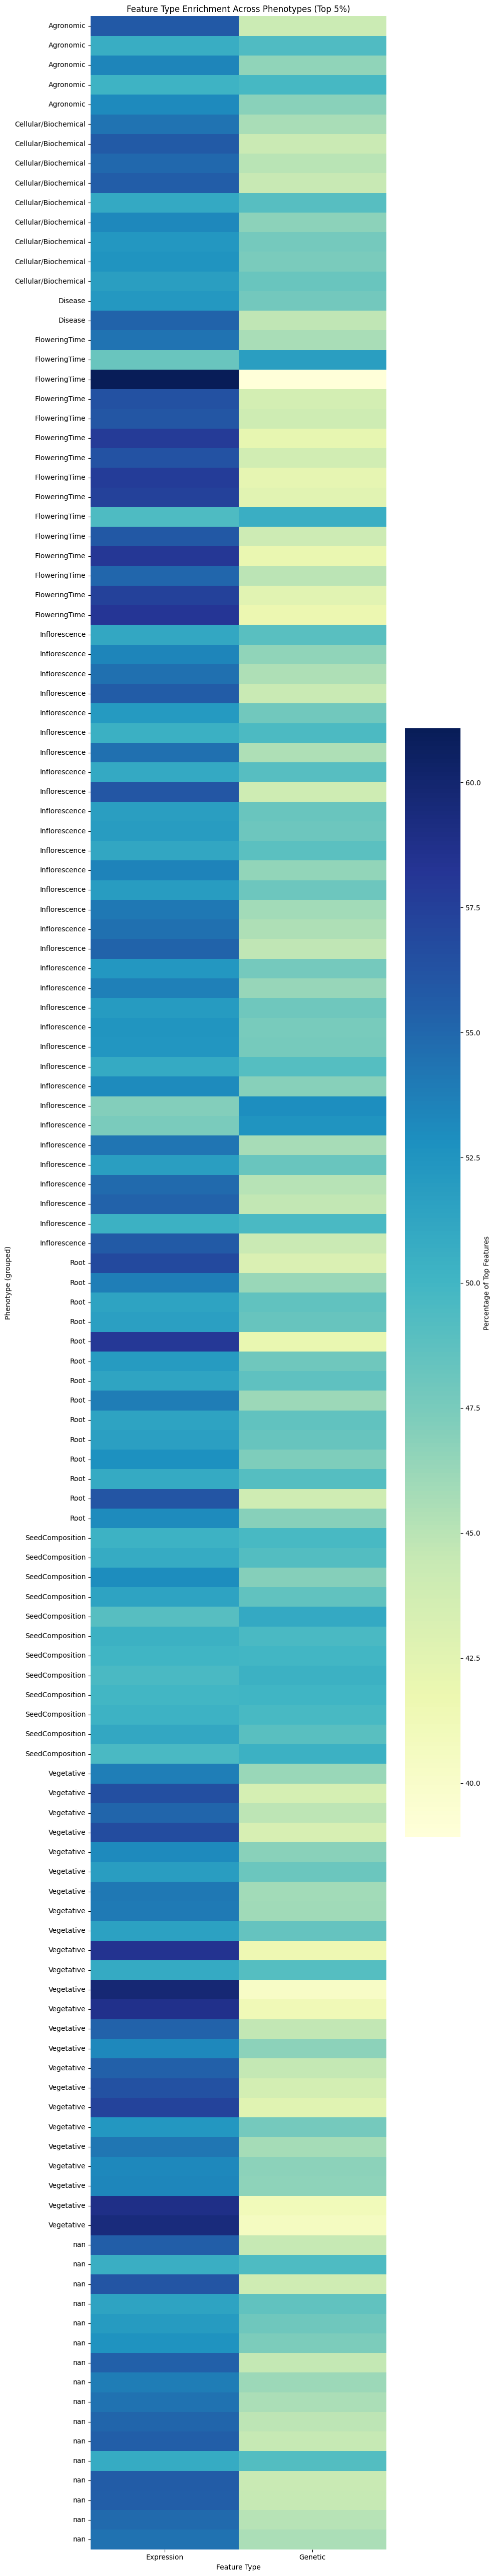

In [203]:
# Add group labels
rrblup_gen_exp_top_5_counts["Group"] = rrblup_gen_exp_top_5_counts.index.map(phenotype_to_group)

# Convert counts to percentages (per phenotype)
percent_table = rrblup_gen_exp_top_5_counts.drop(columns="Group")
percent_table = percent_table.div(percent_table.sum(axis=1), axis=0) * 100

# Reattach group info
percent_table["Group"] = rrblup_gen_exp_top_5_counts["Group"]

# Sort phenotypes by group
percent_table = percent_table.sort_values("Group")

# Drop group column for plotting
plot_table = percent_table.drop(columns="Group")

# Use group labels instead of phenotype names for the y-axis
yticklabels = percent_table["Group"]

# Plot with phenotypes on y-axis
num_pheno = plot_table.shape[0]
fig_height = max(6, 0.4 * num_pheno)

plt.figure(figsize=(10, fig_height))
sns.heatmap(plot_table, annot=False, cmap="YlGnBu",
            cbar_kws={'label': 'Percentage of Top Features'},
            yticklabels=percent_table["Group"])  # phenotypes on y-axis

plt.title("Feature Type Enrichment Across Phenotypes (Top 5%)")
plt.ylabel("Phenotype (grouped)")
plt.xlabel("Feature Type")
plt.tight_layout()
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig5_A.pdf")
plt.show()


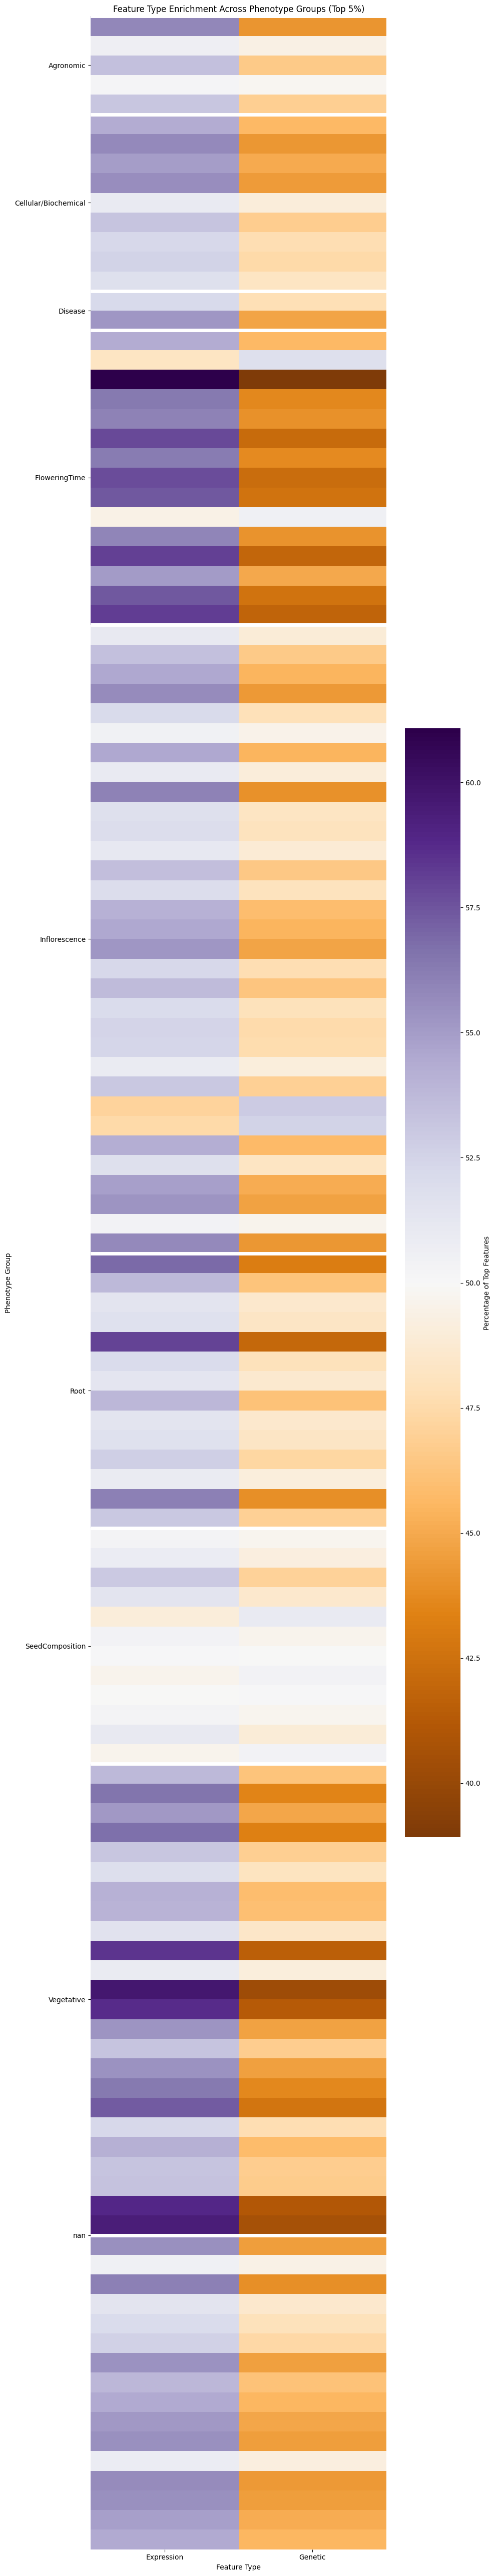

In [ ]:
import numpy as np

plot_table = percent_table.drop(columns="Group")

fig, ax = plt.subplots(figsize=(10, max(6, 0.4 * plot_table.shape[0])))
sns.heatmap(plot_table, annot=False, cmap="PuOr",
            cbar_kws={'label': 'Percentage of Top Features'},
            yticklabels=False, ax=ax)

# Add group dividers + labels
groups = percent_table["Group"]
unique_groups = groups.unique()

tick_positions = []
start = 0
for g in unique_groups:
    count = (groups == g).sum()
    mid = start + count / 2
    tick_positions.append(mid)
    ax.hlines(start, *ax.get_xlim(), colors="white", linewidth=5)
    start += count

# Add last line at end
ax.hlines(start, *ax.get_xlim(), colors="white", linewidth=5)

# Put group names in the middle of each block
ax.set_yticks(tick_positions)
ax.set_yticklabels(unique_groups, rotation=0)

ax.set_title("Feature Type Enrichment Across Phenotype Groups (Top 5%)")
ax.set_ylabel("Phenotype Group")
ax.set_xlabel("Feature Type")
plt.tight_layout()
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig5_A.pdf")
#plt.show()


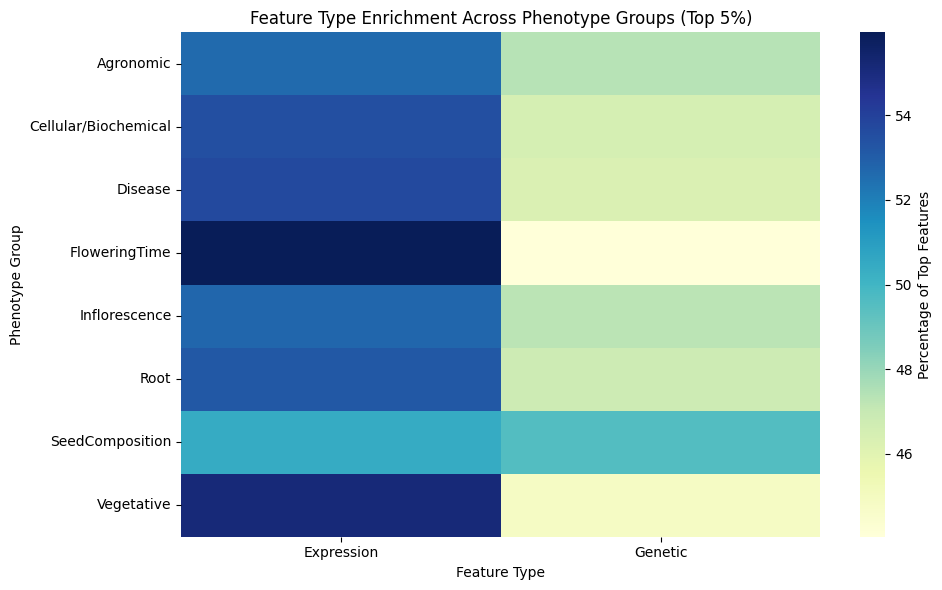

In [205]:
rrblup_gen_exp_top_5_counts["Group"] = rrblup_gen_exp_top_5_counts.index.map(phenotype_to_group)

# Aggregate by group (summing counts across phenotypes in each group)
group_counts = rrblup_gen_exp_top_5_counts.groupby("Group").sum()

# Convert to percentages
percent_table = group_counts.div(group_counts.sum(axis=1), axis=0) * 100

# Plot
num_groups = percent_table.shape[0]
fig_height = max(6, 0.4 * num_groups)

plt.figure(figsize=(10, fig_height))
sns.heatmap(percent_table, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Percentage of Top Features'})
plt.title("Feature Type Enrichment Across Phenotype Groups (Top 5%)")
plt.ylabel("Phenotype Group")
plt.xlabel("Feature Type")
plt.tight_layout()
#plt.savefig("/Users/madisoncreach/Prediction_Project/Figures/Fig5_A.pdf")
plt.show()

In [206]:
# now plot a heatmap showing this data

percent_table = rrblup_gen_exp_top_5_counts.div(rrblup_gen_exp_top_5_counts.sum(axis=1), axis=0) * 100
num_phenotypes = percent_table.shape[0]
fig_height = max(6, 0.2 * num_phenotypes)  # cap at 12 inches

plt.figure(figsize=(10, fig_height))


sns.heatmap(percent_table, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Percentage of Top Features'})
plt.title("Feature Type Enrichment Across Phenotypes (Top 5%)")
plt.ylabel("Phenotype")
plt.xlabel("Feature Type")
plt.tight_layout()
plt.show()


TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [ ]:
# now do the same for all three input spaces

rrblup_features_gen_exp_phen = pd.read_csv("/Users/madisoncreach/Prediction_Project/rrblup_feature_weights_exp_gen_pheno.csv")

In [ ]:
# sort the rrblup features according to absolute weight of the effect size

rr_blup_features_sorted_gen_exp_phen = rrblup_features_gen_exp_phen.copy()
rr_blup_features_sorted_gen_exp_phen['abs_effect'] = rr_blup_features_sorted_gen_exp_phen['Effect'].abs()
rr_blup_features_sorted_gen_exp_phen = rr_blup_features_sorted_gen_exp_phen.sort_values(by=['Phenotype', 'abs_effect'], ascending=[True, False])
rr_blup_features_sorted_gen_exp_phen = rr_blup_features_sorted_gen_exp_phen.drop(columns='abs_effect')

In [ ]:
# now filter the dataframe such that we only have the top 5% of each markers effect

rr_blup_features_sorted_gen_exp_phen_top_5_percent_df = (
    rr_blup_features_sorted_gen_exp.assign(abs_effect=lambda x: x['Effect'].abs())
      .groupby('Phenotype')
      .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])
      .reset_index(drop=True)
      .drop(columns='abs_effect')
)

/var/folders/zb/nzrt7t694fggk1r6y6m3486w0000gn/T/ipykernel_67657/2630119377.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group[group['abs_effect'] >= group['abs_effect'].quantile(0.95)])


In [ ]:
# now add a Feature Type column to the dataframe with a label for each of the data types

rr_blup_features_sorted_gen_exp_phen_top_5_percent_df["FeatureType"] = rr_blup_features_sorted_gen_exp_phen_top_5_percent_df["Marker"].apply(lambda x: "Expression" if x.startswith("Zm") else ("Genetic" if x.startswith("chr") else "Phenomic"))

In [ ]:
# now get a count of each of the feature types according to their respective phenotype

rrblup_gen_exp_phen_top_5_counts = rr_blup_features_sorted_gen_exp_phen_top_5_percent_df.groupby(["Phenotype", "FeatureType"]).size().unstack(fill_value=0)

In [ ]:
# now add a Feature Type column to the dataframe with a label for each of the data types

rr_blup_features_sorted_gen_exp_phen["FeatureType"] = rr_blup_features_sorted_gen_exp_phen["Marker"].apply(lambda x: "Expression" if x.startswith("Zm") else ("Genetic" if x.startswith("chr") else "Phenomic"))

In [ ]:
# now get a count of each of the feature types according to their respective phenotype

rrblup_gen_exp_phen_background_counts = rr_blup_features_sorted_gen_exp_phen.groupby(["Phenotype", "FeatureType"]).size().unstack(fill_value=0)

In [ ]:
print(rrblup_gen_exp_phen_background_counts)

FeatureType              Expression  Genetic  Phenomic
Phenotype                                             
ASIGDD_L                      28221    34153       950
ASI_L                         28221    34153       950
AnkomCrudeFiber_K             28221    34153       950
Anthesis1_L                   28221    34153       950
Anthesis4_H                   28221    34153       950
...                             ...      ...       ...
VascularBundleDensity_D       28221    34153       950
Weight.g                      28221    34153       950
avgEH_N                       28221    34153       950
dry_g_per_ear                 28221    34153       950
peri_N                        28221    34153       950

[129 rows x 3 columns]
